In [1]:
channel_name = 'build-with-brandon'

In [3]:
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()

# Retrieve API key from environment variables
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

# Verify API key is loaded
if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")
    
youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [5]:
def get_quota_reset_info():
    """Get information about when quota resets and suggest action"""
    from datetime import datetime, timezone, timedelta
    import pytz
    
    pacific = pytz.timezone('America/Los_Angeles')
    now_pt = datetime.now(pacific)
    
    # Calculate next reset time (midnight PT)
    reset_time = now_pt.replace(hour=0, minute=0, second=0, microsecond=0)
    if now_pt >= reset_time:
        reset_time += timedelta(days=1)
    
    time_until_reset = reset_time - now_pt
    hours_until_reset = time_until_reset.total_seconds() / 3600
    
    print(f"Current PT time: {now_pt.strftime('%H:%M')}")
    print(f"Quota resets in: {hours_until_reset:.1f} hours")
    
    if hours_until_reset < 4:
        print("⚠️  Caution: Limited time until quota reset")
        if hours_until_reset < 1:
            print("✅ Consider waiting for fresh quota")
    
    return hours_until_reset

# Use it like this:
if get_quota_reset_info() < 2:
    # Very little time until reset
    print("You might want to wait for quota reset")

Current PT time: 07:37
Quota resets in: 16.4 hours


In [7]:
def get_channel(channel_name):
    return youtube.search().list(q=channel_name, type='channel', part='id,snippet').execute()['items'][0]

channel_id = get_channel(channel_name)['id']['channelId']
channel_id

'UCem88DctD18yfBeA91ytmbg'

In [48]:
channel_id = 'UCsv6YMh5kLhixuepSEzHKzg'
UCsv6YMh5kLhixuepSEzHKzg

In [50]:
# Search for channels matching your channel name
search_response = youtube.search().list(
    q=channel_name,
    type='channel',
    part='id,snippet',
    maxResults=10  # Get more results
).execute()

print(f"Found {len(search_response['items'])} channels matching '{channel_name}':\n")

for i, item in enumerate(search_response['items']):
    channel_id = item['id']['channelId']
    channel_title = item['snippet']['title']
    description = item['snippet']['description'][:100] if item['snippet']['description'] else 'No description'
    
    # Get subscriber count for each channel
    stats_request = youtube.channels().list(
        part="statistics",
        id=channel_id
    ).execute()
    
    if stats_request['items']:
        subs = stats_request['items'][0]['statistics'].get('subscriberCount', 'Hidden')
        videos = stats_request['items'][0]['statistics'].get('videoCount', 'Unknown')
    else:
        subs = 'Unknown'
        videos = 'Unknown'
    
    print(f"{i+1}. Channel: {channel_title}")
    print(f"   ID: {channel_id}")
    print(f"   Subscribers: {subs}")
    print(f"   Videos: {videos}")
    print(f"   Description: {description[:100]}")
    print()

Found 10 channels matching 'build-with-brandon':

1. Channel: BradenBuildz
   ID: UCem88DctD18yfBeA91ytmbg
   Subscribers: 263000
   Videos: 59
   Description: We fix broken things here. And sometimes break them. (Not A Mechanic) Possum Trot KY  SELL ME your u

2. Channel: Make With Brandon
   ID: UCT9vmDD4KrgBbaoOBftLq7w
   Subscribers: 161000
   Videos: 61
   Description: Hey, I'm Brandon. This channel is all about trying new things and letting my creativity take the lea

3. Channel: Build With Brandon
   ID: UC43vO1QcCxj0gvTBNaeBTdA
   Subscribers: 3
   Videos: 3
   Description: Dive into the world of serene creativity with our soothing building block sets channel. As tranquil 

4. Channel: Build With Brandon 
   ID: UCf6cCpCqOl_mr3_Nf5CRD2A
   Subscribers: 21
   Videos: 14
   Description: Hey, I'm Brandon Moore, a highly enthusiastic Real Estate Agent servicing the Connecticut area. My m

5. Channel: Building with Brandon
   ID: UCU3GoUmkiZlPvUCFxyPx8BA
   Subscribers: 6
   Videos:

In [52]:
# Search for the exact video you want
video_query = "OpenCode Tutorial for Beginners Learn 90% Of OpenCode in Under 25 Minutes"

video_search = youtube.search().list(
    q=video_query,
    type='video',
    part='id,snippet',
    maxResults=10
).execute()

print(f"Found {len(video_search['items'])} videos:\n")

for i, item in enumerate(video_search['items']):
    video_title = item['snippet']['title']
    channel_title = item['snippet']['channelTitle']
    channel_id = item['snippet']['channelId']
    video_id = item['id']['videoId']
    description = item['snippet']['description'][:150] if item['snippet']['description'] else 'No description'
    
    print(f"{i+1}. Video: {video_title}")
    print(f"   Channel: {channel_title}")
    print(f"   Channel ID: {channel_id}")
    print(f"   Video ID: {video_id}")
    print(f"   Description: {description}")
    print()
    
    # Check if this is the right channel by looking at its description
    if "Want to learn the latest and best ways to use AI" in description:
        print("   ✅ THIS IS THE RIGHT CHANNEL!")
        correct_channel_id = channel_id
        print(f"   Use this Channel ID: {correct_channel_id}")

Found 10 videos:

1. Video: OpenCode Tutorial for Beginners: Learn 90% Of OpenCode in Under 25 Minutes
   Channel: Brandon Melville
   Channel ID: UCsv6YMh5kLhixuepSEzHKzg
   Video ID: QzqaZshQcJI
   Description: Join my Skool: https://clickmoney.io/gzkqjw9n-lnk-xagy9gzx In this detailed tutorial, I walk you through everything you need to ...

2. Video: Claude Code Tutorial for Beginners
   Channel: Sabrina Ramonov 🍄
   Channel ID: UCiGWNa6QK6CiKPvv5-YPv8g
   Video ID: 3HVH2Iuplqo
   Description: Easiest way to learn AI (free): https://www.sabrina.dev 50% OFF 1st month Blotato (promo code SPRING2026 & extra 5000 ...

3. Video: The Ultimate Local AI Coding Guide For 2026
   Channel: Zen van Riel
   Channel ID: UC7TUInmEJ4NmYb-krFz-SuA
   Video ID: rp5EwOogWEw
   Description: Get my FREE local AI projects: https://zenvanriel.com/open-source ⚡ Master AI and become a high-paid AI Engineer: ...

4. Video: 99% Of Devs Don&#39;t Understand Spring Boot
   Channel: CodeHead
   Channel ID: UCFVt

# Diving into YouTube Analytics
Deepnote presented a live stream featuring a showcase of how to use Google's YouTube API. We had a few Deepnote coders and a Deepnote user Allan who helped crack the API and start getting data. Below is a project inspired from that stream!

In this notebook we are going to dive in and check out the popular YouTube channel Good Mythical Morning.

## API Functions
In this section we setup some API functions to help us gather data. We create a function to gather channel stats and video stats. To do this in a effecient way and save API calls we do not use the search function. We pull in GMM's upload playlist ( containing all of their videos ) and use that to build a video list. Then grab the data from each video.

In [56]:
# Function to get the channels stats
# It will also contain the upload playlist ID we can use to grab videos.
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    
    return response['items']

In [58]:
# This will get us a list of videos from a playlist.
# Note a page of results has a max value of 50 so we will
# need to loop over our results with a pageToken

def get_video_list(youtube, upload_id):
    video_list = []
    request = youtube.playlistItems().list(
        part="snippet,contentDetails",
        playlistId=upload_id,
        maxResults=50
    )
    next_page = True
    while next_page:
        response = request.execute()
        data = response['items']

        for video in data:
            video_id = video['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)

        # Do we have more pages?
        if 'nextPageToken' in response.keys():
            next_page = True
            request = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=upload_id,
                pageToken=response['nextPageToken'],
                maxResults=50
            )
        else:
            next_page = False

    return video_list

In [60]:
# new function
def get_video_details(youtube, video_list):
    stats_list = []

    # Can only get 50 videos at a time.
    for i in range(0, len(video_list), 50):
        request = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )

        data = request.execute()
        for video in data['items']:
            video_id = video['id']  # Extract video_id 
            title = video['snippet']['title']
            published = video['snippet']['publishedAt']
            description = video['snippet']['description']
            view_count = video['statistics'].get('viewCount', 0)
            like_count = video['statistics'].get('likeCount', 0)
            dislike_count = video['statistics'].get('dislikeCount', 0)
            comment_count = video['statistics'].get('commentCount', 0)
            duration = video['contentDetails'].get('duration', 'Unknown')  # Use .get() with a default value

            # Include video_id in the dictionary
            stats_dict = dict(
                video_id=video_id,
                title=title,
                description=description,
                published=published,
                view_count=view_count,
                like_count=like_count,
                dislike_count=dislike_count,
                comment_count=comment_count,
                duration=duration             
            )
            stats_list.append(stats_dict)

    return stats_list

In [62]:
def convert_iso_duration_to_hms(duration):
    """
    Converts an ISO 8601 duration string (e.g., 'PT3M54S') to 'H:M:S' format.
    
    Args:
        duration (str): The ISO 8601 duration string (e.g., 'PT3M54S').
    
    Returns:
        str: The duration in 'H:M:S' format.
    """
    # Regex to extract hours, minutes, and seconds from the ISO 8601 duration
    pattern = re.compile(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?')
    match = pattern.match(duration)
    
    if not match:
        return "0:00:00"  # Default if the format is invalid
    
    # Extract hours, minutes, and seconds
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    
    # Create a timedelta object
    delta = timedelta(hours=hours, minutes=minutes, seconds=seconds)
    
    # Convert to total seconds
    total_seconds = int(delta.total_seconds())
    
    # Convert total seconds to H:M:S format
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    
    return f"{hours}:{minutes:02d}:{seconds:02d}"

## Create our Channel Stats

In [65]:
channel_stats = get_channel_stats(youtube, channel_id)

## Find our Upload Playlist ( will contain all video uploads )

In [68]:
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
upload_id

'UU2b2wgxm0vFjQfJJ0iRcFRw'

## Get our Video List

In [101]:
def get_all_channel_videos_direct(youtube, channel_id, max_results=100):
    """
    Get videos directly using search API instead of uploads playlist
    """
    video_list = []
    next_page_token = None
    
    while len(video_list) < max_results:
        search_request = youtube.search().list(
            channelId=channel_id,
            type='video',
            part='id,snippet',
            maxResults=50,
            pageToken=next_page_token,
            order='date'  # Get most recent videos first
        )
        search_response = search_request.execute()
        
        for item in search_response['items']:
            video_id = item['id']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)
        
        next_page_token = search_response.get('nextPageToken')
        if not next_page_token or len(video_list) >= max_results:
            break
    
    return video_list

# Test with your channel ID
YOUR_CHANNEL_ID = 'UCsv6YMh5kLhixuepSEzHKzg'  # Replace with the correct ID

# Get videos directly
video_list = get_all_channel_videos_direct(youtube, YOUR_CHANNEL_ID)
print(f"Found {len(video_list)} videos")

# Get video details
video_data = get_video_details(youtube, video_list)
df = pd.DataFrame(video_data)
print(f"Fetched details for {len(df)} videos")

Found 76 videos
Fetched details for 76 videos


In [99]:
video_list = get_video_list(youtube, upload_id)

## Get our Video Details
Finally we will get all of our videos details returned in a dictionary.

In [74]:
video_data = get_video_details(youtube, video_list)
'Number 0f Videos: ' + str(len(video_data))

'Number 0f Videos: 268'

## Pause and think what to do next

In [103]:
df=pd.DataFrame(video_data)
df.shape

(76, 9)

In [105]:
df['title_length'] = df['title'].str.len()
df["view_count"] = pd.to_numeric(df["view_count"])
df["like_count"] = pd.to_numeric(df["like_count"])
df["dislike_count"] = pd.to_numeric(df["dislike_count"])
df["comment_count"] = pd.to_numeric(df["comment_count"])
df["published"] = pd.to_datetime(df["published"])
# Format the 'published' column to "%Y-%m-%d"
df["published"] = df["published"].dt.strftime("%Y-%m-%d")
# reaction used later add up likes + dislikes + comments
df["reactions"] = df["like_count"] + df["dislike_count"] + df["comment_count"] + df["comment_count"]
df['hms_format'] = df['duration'].apply(convert_iso_duration_to_hms)

In [109]:
# Select rows where the title contains "Animation Maker"
#result = df
result = df.query('title.str.lower().str.contains("opencode")', engine='python')
result.shape

(10, 12)

In [111]:
# Filter your existing dataframe for the specific video
specific_video = df[df['title'].str.contains("OpenCode Tutorial for Beginners", case=False, na=False)]

if not specific_video.empty:
    print(f"Found {len(specific_video)} matching videos:")
    display(specific_video[cols])
else:
    print("Video not found in current dataset. Try refreshing your video list.")

Found 1 matching videos:


,video_id,title,published,view_count,title_length,hms_format
18,QzqaZshQcJI,OpenCode Tutorial for Beginners: Learn 90% Of OpenCode in Under 25 Minutes,2026-02-19,79158,74,0:24:04


In [113]:
cols = 'video_id title published view_count title_length hms_format'.split()

In [115]:
# Retrieve the maximum value from the title_length column
max_title_length = result['title_length'].max()
print("Maximum title length:", max_title_length)
# Set pandas column display width to the maximum title_length value
pd.set_option('display.max_colwidth', max_title_length)
result[cols].sort_values(by='published', ascending=False).head(30)

Maximum title length: 74


,video_id,title,published,view_count,title_length,hms_format
0,_BLcKahtIKA,"This Plugin Gives OpenCode Superpowers, Here's How...",2026-04-24,9386,53,0:09:15
1,772tEBPfutI,"Toad: One Interface for Every AI Coder (OpenCode, Claude, Cursor, More)",2026-04-21,3633,71,0:06:16
3,TO_uBWT5Dt4,OpenCode + Stitch = AMAZING Websites Insanely Fast,2026-04-08,2471,50,0:15:37
4,lfAKPQVSxDs,OpenCode Custom Agents,2026-03-16,1036,22,0:01:00
5,CCUV1YzVYzg,Google’s New Tool Makes OpenCode WAY More Useful,2026-03-15,10283,48,0:15:14
6,WQ6xcjB-tqU,OpenCode Agents in 16 Minutes & my best tips,2026-03-07,31211,44,0:16:31
14,oLttKbt-C1w,Free Models on OpenCode #ai #vibecoding,2026-02-19,308,39,0:00:48
15,-pu4WG21kNw,why choose OpenCode instead of Claude Code,2026-02-19,1076,42,0:00:23
17,brLPZ3-yXAc,OpenCode vs Claude Code,2026-02-19,753,24,0:00:44
18,QzqaZshQcJI,OpenCode Tutorial for Beginners: Learn 90% Of OpenCode in Under 25 Min...,2026-02-19,79158,74,0:24:04


## Most Viewed Videos

In [118]:
df_highest_views = result.nlargest(10, 'view_count')
df_highest_views['title'] = df_highest_views['title'].str[:94]
df_highest_views['view_count_millions'] = df_highest_views['view_count'] / 5000
df_highest_views[cols]

,video_id,title,published,view_count,title_length,hms_format
18,QzqaZshQcJI,OpenCode Tutorial for Beginners: Learn 90% Of OpenCode in Under 25 Min...,2026-02-19,79158,74,0:24:04
6,WQ6xcjB-tqU,OpenCode Agents in 16 Minutes & my best tips,2026-03-07,31211,44,0:16:31
5,CCUV1YzVYzg,Google’s New Tool Makes OpenCode WAY More Useful,2026-03-15,10283,48,0:15:14
0,_BLcKahtIKA,"This Plugin Gives OpenCode Superpowers, Here's How...",2026-04-24,9386,53,0:09:15
1,772tEBPfutI,"Toad: One Interface for Every AI Coder (OpenCode, Claude, Cursor, More)",2026-04-21,3633,71,0:06:16
3,TO_uBWT5Dt4,OpenCode + Stitch = AMAZING Websites Insanely Fast,2026-04-08,2471,50,0:15:37
15,-pu4WG21kNw,why choose OpenCode instead of Claude Code,2026-02-19,1076,42,0:00:23
4,lfAKPQVSxDs,OpenCode Custom Agents,2026-03-16,1036,22,0:01:00
17,brLPZ3-yXAc,OpenCode vs Claude Code,2026-02-19,753,24,0:00:44
14,oLttKbt-C1w,Free Models on OpenCode #ai #vibecoding,2026-02-19,308,39,0:00:48


In [120]:
df_highest_views[cols].sort_values(by="published",ascending=False)

,video_id,title,published,view_count,title_length,hms_format
0,_BLcKahtIKA,"This Plugin Gives OpenCode Superpowers, Here's How...",2026-04-24,9386,53,0:09:15
1,772tEBPfutI,"Toad: One Interface for Every AI Coder (OpenCode, Claude, Cursor, More)",2026-04-21,3633,71,0:06:16
3,TO_uBWT5Dt4,OpenCode + Stitch = AMAZING Websites Insanely Fast,2026-04-08,2471,50,0:15:37
4,lfAKPQVSxDs,OpenCode Custom Agents,2026-03-16,1036,22,0:01:00
5,CCUV1YzVYzg,Google’s New Tool Makes OpenCode WAY More Useful,2026-03-15,10283,48,0:15:14
6,WQ6xcjB-tqU,OpenCode Agents in 16 Minutes & my best tips,2026-03-07,31211,44,0:16:31
18,QzqaZshQcJI,OpenCode Tutorial for Beginners: Learn 90% Of OpenCode in Under 25 Min...,2026-02-19,79158,74,0:24:04
15,-pu4WG21kNw,why choose OpenCode instead of Claude Code,2026-02-19,1076,42,0:00:23
17,brLPZ3-yXAc,OpenCode vs Claude Code,2026-02-19,753,24,0:00:44
14,oLttKbt-C1w,Free Models on OpenCode #ai #vibecoding,2026-02-19,308,39,0:00:48


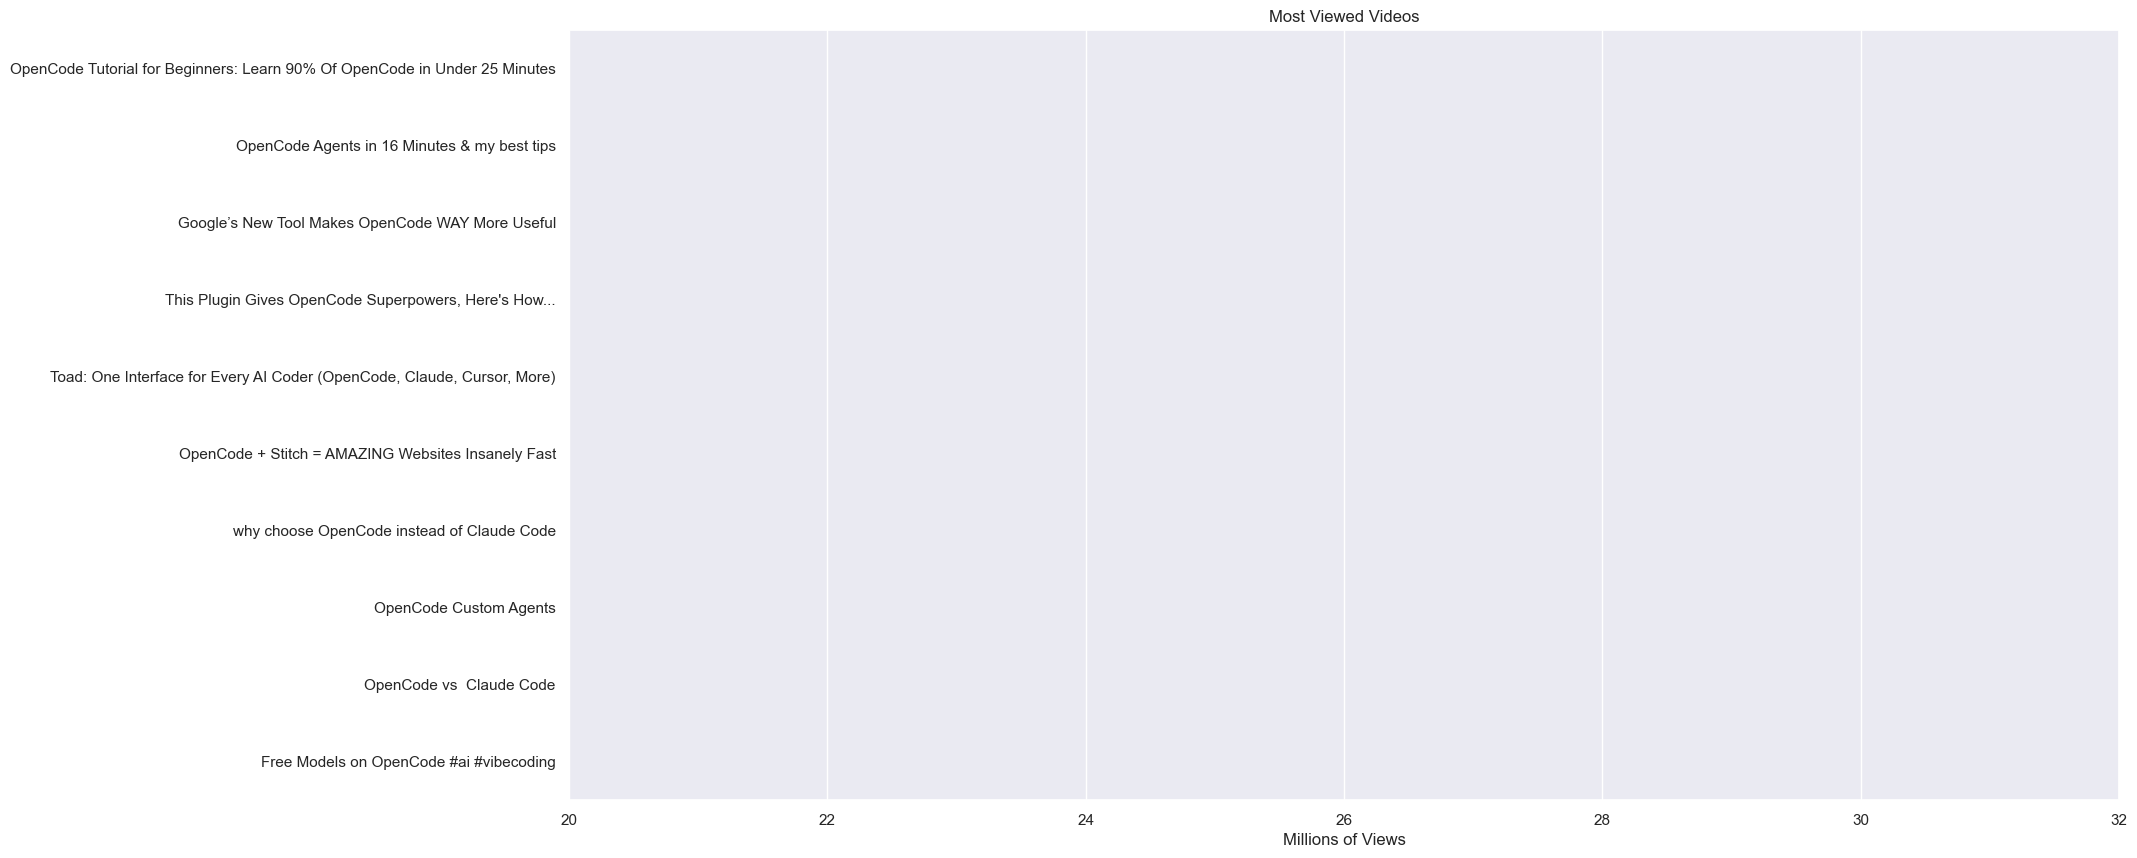

In [122]:
# Set the figure size
sns.set(rc={'figure.figsize': (20, 10)})

# Create the barplot
plot = sns.barplot(
    x="view_count_millions", 
    y="title", 
    hue="title",  # Assign y variable to hue
    data=df_highest_views, 
    palette="bright", 
    legend=False  # Disable the legend
)

# Set labels and title
plot.set(xlabel='Millions of Views', ylabel='')
plot.set_title('Most Viewed Videos')

# Set x-axis limits
plt.xlim(20, 32)

# Show the plot
plt.show()

In [124]:
colt = 'video_id title published view_count hms_format'.split()
output_file = channel_name + '.csv'
result[colt].to_csv(output_file, index=None)
result[colt].sort_values(by="published",ascending=False)

,video_id,title,published,view_count,hms_format
0,_BLcKahtIKA,"This Plugin Gives OpenCode Superpowers, Here's How...",2026-04-24,9386,0:09:15
1,772tEBPfutI,"Toad: One Interface for Every AI Coder (OpenCode, Claude, Cursor, More)",2026-04-21,3633,0:06:16
3,TO_uBWT5Dt4,OpenCode + Stitch = AMAZING Websites Insanely Fast,2026-04-08,2471,0:15:37
4,lfAKPQVSxDs,OpenCode Custom Agents,2026-03-16,1036,0:01:00
5,CCUV1YzVYzg,Google’s New Tool Makes OpenCode WAY More Useful,2026-03-15,10283,0:15:14
6,WQ6xcjB-tqU,OpenCode Agents in 16 Minutes & my best tips,2026-03-07,31211,0:16:31
14,oLttKbt-C1w,Free Models on OpenCode #ai #vibecoding,2026-02-19,308,0:00:48
15,-pu4WG21kNw,why choose OpenCode instead of Claude Code,2026-02-19,1076,0:00:23
17,brLPZ3-yXAc,OpenCode vs Claude Code,2026-02-19,753,0:00:44
18,QzqaZshQcJI,OpenCode Tutorial for Beginners: Learn 90% Of OpenCode in Under 25 Min...,2026-02-19,79158,0:24:04


In [126]:
# Get the user's home directory
user_path = os.path.expanduser('~')
# Get the current working directory
current_path = os.getcwd()
# Derive the base directory (base_dir) by removing the last folder ('Daily')
base_path = os.path.dirname(current_path)
#C:\Users\PC1\OneDrive\A5\Excel
xsl_path = os.path.join(base_path, "Excel")

In [128]:
print("User path:", user_path)
print(f"Current path: {current_path}")
print(f"Base path: {base_path}")
print(f"Excel path (xsl_path): {xsl_path}")

User path: C:\Users\PC1
Current path: C:\Users\PC1\OneDrive\A4\YouTube
Base path: C:\Users\PC1\OneDrive\A4
Excel path (xsl_path): C:\Users\PC1\OneDrive\A4\Excel


In [130]:
xsl_file = channel_name + '.xlsx'
xsl_file = os.path.join(xsl_path, xsl_file)
xsl_file

'C:\\Users\\PC1\\OneDrive\\A4\\Excel\\build-with-brandon.xlsx'

In [132]:
colt = 'video_id title published view_count hms_format read'.split()
df_highest_views['read'] = 'N'
df_highest_views[colt].to_excel(xsl_file, index=False)